In [5]:
# Run configuration
FRACTION = 0.2  # subset run
RANDOM_STATE = 42

# Neural Network COPD Risk Modeling Notebook

This notebook builds a COPD risk classifier using ONLY neural network (MLP) models. The workflow emphasizes rigorous feature engineering, careful data quality handling, class imbalance mitigation, calibrated probability outputs, and threshold optimization for F1.

## Pipeline Overview
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Cleaning
   - Anthropometrics (BMI, waist-to-height)
   - Derived metabolic score & lipid ratios
   - Age interaction & polynomial terms
   - Outlier mitigation (winsorization) & skew handling (log1p)
   - Vision/hearing anomaly nulling
   - Binary encoding of categorical flags
3. Correlation Computation (point-biserial) and persistence to `feature_target_correlation.csv`
4. Baseline MLP + Randomized Hyperparameter Search (quick) with oversampling
5. Threshold Optimization on Out-of-Fold (OOF) predictions for maximal F1; prediction file `nn.csv`
6. Extended Hyperparameter Search (broader architecture space)
7. Manual Platt (sigmoid) Calibration for probability refinement; outputs `nn_calibrated.csv`
8. Feature Interaction & Non-linear Augmentation + Deeper MLP architecture; outputs `nn_augmented.csv`

## Imbalance Strategy
Instead of sample weights (not supported by scikit-learn MLP), random oversampling balances classes inside the pipeline prior to fitting.

## Metrics Focus
Primary: F1 (due to class imbalance). Secondary: Brier score (calibration quality).

## Artifacts Produced
- `feature_target_correlation.csv`
- `nn.csv` + `nn_threshold.txt`
- `nn_calibrated.csv` + `nn_threshold_calibrated.txt`
- `nn_augmented.csv` + `nn_threshold_augmented.txt`

Proceed through sections sequentially; each code block is now heavily commented for clarity.

## 1. Exploratory Data Analysis (EDA)

The goal of EDA here is lightweight sanity checking:

- Inspect shape, head, and missingness distribution.

- Review target balance (class imbalance severity).

- Plot a small sample of numeric feature distributions to spot skew, outliers, or implausible ranges.



Heavy EDA (correlations, pairplots) is deferred; we only need enough to guide cleaning & transformations. Subsequent feature engineering incorporates domain-inspired ratios and transformations.



Run the following cell to perform the basic inspection.

train shape: (8911, 27) FRACTION= 0.2


,patient_id,sex,age_group,height_cm,weight_kg,waist_circumference_cm,vision_left,vision_right,hearing_left,hearing_right,...,hemoglobin_level,urine_protein_level,serum_creatinine,ast_enzyme_level,alt_enzyme_level,ggt_enzyme_level,oral_health_status,dental_cavity_status,tartar_presence,has_copd_risk
0,50032,M,25,175,70,85.0,1.0,1.0,1.0,1.0,...,17.8,1.0,0.9,27.0,26.0,25.0,Y,0,Y,0
1,45440,M,40,165,80,98.9,1.2,1.2,1.0,1.0,...,18.0,3.0,1.0,27.0,30.0,121.0,Y,0,Y,1
2,31245,M,40,175,80,88.0,1.0,1.0,1.0,1.0,...,14.5,1.0,0.9,17.0,9.0,13.0,Y,1,Y,1
3,36676,F,40,165,60,77.0,0.8,1.5,1.0,1.0,...,11.7,1.0,0.7,27.0,18.0,15.0,Y,0,Y,0
4,38741,F,45,160,60,77.1,0.8,0.9,1.0,1.0,...,13.6,1.0,0.9,24.0,21.0,16.0,Y,0,Y,0



Missing value percent:
patient_id              0.0
triglycerides           0.0
tartar_presence         0.0
dental_cavity_status    0.0
oral_health_status      0.0
ggt_enzyme_level        0.0
alt_enzyme_level        0.0
ast_enzyme_level        0.0
serum_creatinine        0.0
urine_protein_level     0.0
hemoglobin_level        0.0
ldl_cholesterol         0.0
hdl_cholesterol         0.0
total_cholesterol       0.0
sex                     0.0
fasting_glucose         0.0
bp_diastolic            0.0
bp_systolic             0.0
hearing_right           0.0
hearing_left            0.0
dtype: float64

Target balance:
has_copd_risk
0    0.636741
1    0.363259
Name: proportion, dtype: float64
Numeric columns sample: ['patient_id', 'age_group', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'vision_left', 'vision_right', 'hearing_left', 'hearing_right', 'bp_systolic']


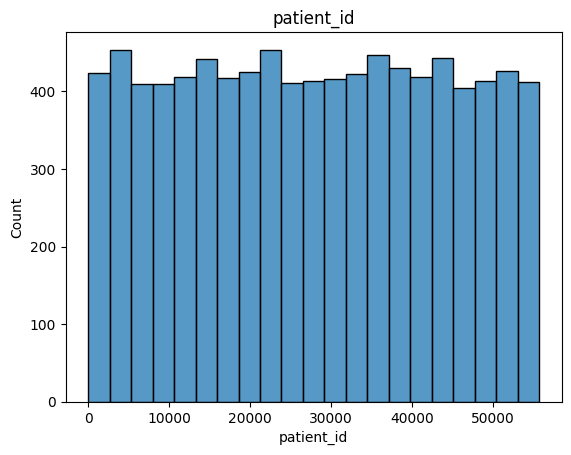

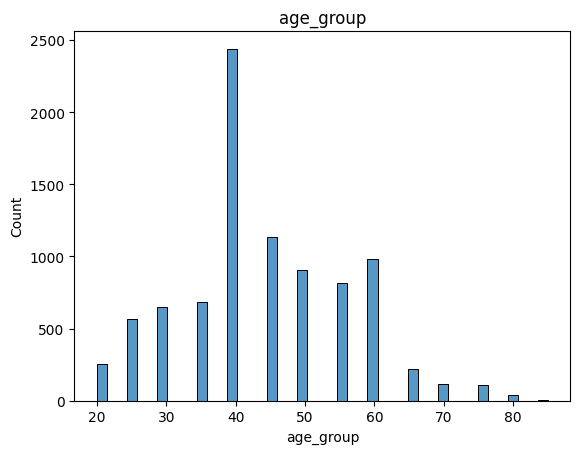

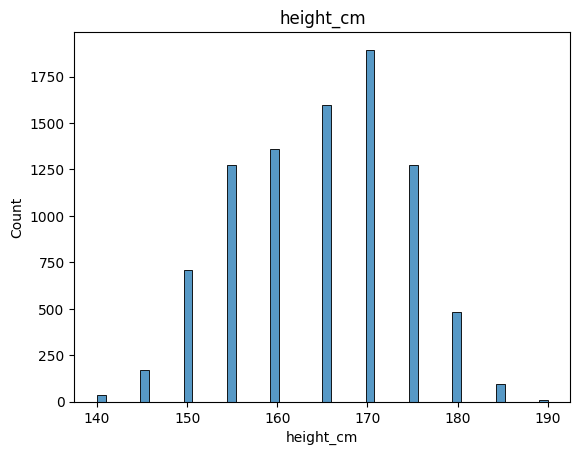

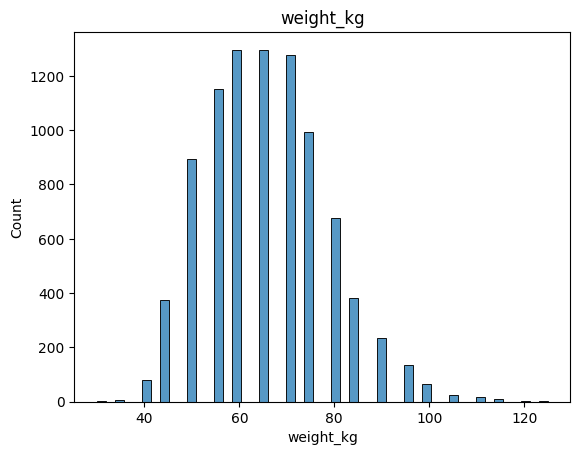

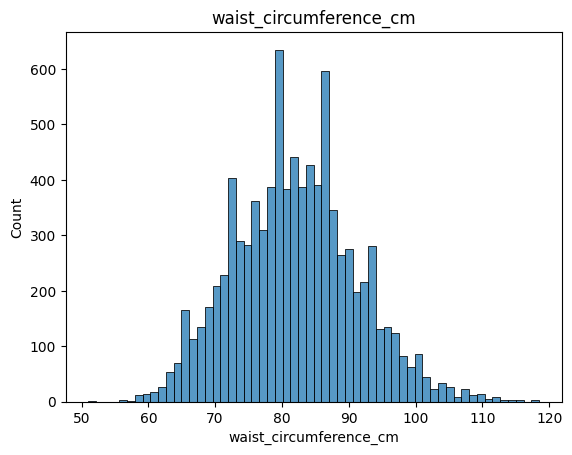

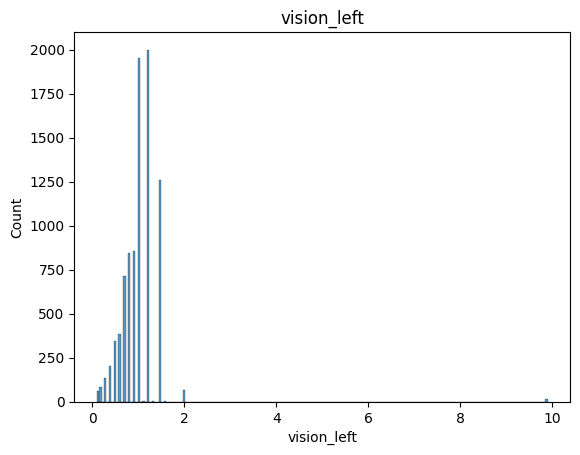

In [6]:
# --- EDA: load and inspect basic structure & distributions ---
# Imports kept local here for clarity; global imports appear later where reused.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load training data (absolute path for reliability)
train = pd.read_csv('/Users/vaishak/Desktop/Chronic_disease_ML/chronic-obstructive-pulmonary-disease-copd-risk/train.csv')
if FRACTION < 1.0:
    train = train.sample(frac=FRACTION, random_state=RANDOM_STATE).reset_index(drop=True)
print('train shape:', train.shape, 'FRACTION=', FRACTION)

# Head preview (display available only in notebooks environment; fallback print otherwise)
try:
    display(train.head())
except NameError:
    print(train.head())

# Missingness (top 20 by percentage) guides imputation strategy (median later)
print('\nMissing value percent:')
print((train.isnull().mean()*100).sort_values(ascending=False).head(20))

# Target class imbalance check (numeric normalization to view proportions)
if 'has_copd_risk' in train.columns:
    print('\nTarget balance:')
    print(train['has_copd_risk'].value_counts(dropna=False, normalize=True))

# Quick distribution plots for first few numeric columns
# Purpose: identify obvious skew/outliers prompting winsorization & log1p transforms.
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns sample:', num_cols[:10])
for c in num_cols[:6]:
    try:
        sns.histplot(train[c].dropna(), kde=False)
        plt.title(c)
        plt.show()
    except Exception as e:
        print('Plot skipped for', c, e)


## 2. Feature Engineering & Data Cleaning

This section constructs derived physiological & metabolic features plus quality improvements:

- BMI and waist-to-height ratio: normalize for height; obesity indicators.

- Age interactions & polynomial (age_squared) to allow non-linear age effects.

- Lipid ratios (cholesterol/HDL, LDL/HDL): cardiovascular/metabolic risk proxies.

- Metabolic composite score: standardized average of key metabolic indicators.

- Winsorization (1% / 99%) on skewed numeric features to reduce extreme outlier influence.

- Log1p transforms for right-skewed labs to compress dynamic range.

- Vision/hearing anomaly nulling: remove implausible measurement codes (>5 or ==9.9) prior to imputation.

- Binary encoding of categorical flags (sex, oral health, tartar presence) for direct NN consumption.

- Point-biserial correlations are calculated to persist feature-target relationship strength.



After engineering:

1. Median imputation across all numeric columns.

2. Standard scaling (later, dual scaling for augmented set).

3. Oversampling applied inside pipeline during model fitting for class imbalance.



Proceed to run the next code cell implementing the transformations and initial model search.

In [7]:
# --- Feature Engineering, Correlation Computation, Baseline MLP Search, Threshold Optimization ---
# Subsampling via FRACTION already applied only to train in earlier cell. We re-load full train/test here but
# will apply the same FRACTION to maintain consistency.

import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, f1_score
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin, clone

# Load data (train/test). `X` excludes ID and target.
train_full = pd.read_csv('/Users/vaishak/Desktop/Chronic_disease_ML/chronic-obstructive-pulmonary-disease-copd-risk/train.csv')
if FRACTION < 1.0:
    train_full = train_full.sample(frac=FRACTION, random_state=RANDOM_STATE).reset_index(drop=True)
print('Reloaded train with FRACTION:', FRACTION, 'shape:', train_full.shape)

test = pd.read_csv('/Users/vaishak/Desktop/Chronic_disease_ML/chronic-obstructive-pulmonary-disease-copd-risk/test.csv')
y = train_full['has_copd_risk']
X = train_full.drop(columns=['patient_id','has_copd_risk'])

# ---------------- Feature Engineering & Cleaning ----------------
NUM_WINSOR = ['triglycerides','fasting_glucose','waist_circumference_cm','bmi']  # bmi appended dynamically after creation
LOG_FEATURES = ['triglycerides','ggt_enzyme_level','alt_enzyme_level','ast_enzyme_level']
VISION_HEARING_COLS = ['vision_left','vision_right','hearing_left','hearing_right']

def winsorize_series(s, lower=0.01, upper=0.99):
    """Clip values to specified quantiles to limit outlier impact."""
    if s.isnull().all():
        return s
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

def feature_engineer(df):
    """Create derived physiological & metabolic features and apply cleaning/transforms."""
    df = df.copy()
    # BMI & waist-to-height ratio
    if 'height_cm' in df.columns and 'weight_kg' in df.columns:
        h_m = df['height_cm'] / 100.0
        denom = (h_m * h_m).replace({0: np.nan})
        df['bmi'] = df['weight_kg'] / denom
        if 'waist_circumference_cm' in df.columns:
            df['waist_to_height'] = df['waist_circumference_cm'] / df['height_cm'].replace({0: np.nan})
    # Age interactions / polynomial
    if 'age_group' in df.columns:
        if 'bmi' in df.columns:
            df['bmi_age'] = df['bmi'] * df['age_group']
        df['age_squared'] = df['age_group'] ** 2
    # Sex encoding
    if 'sex' in df.columns:
        df['sex_f'] = df['sex'].map({'M':0,'F':1})
    # Binary flags
    for col in ['oral_health_status','tartar_presence']:
        if col in df.columns:
            df[col + '_bin'] = df[col].map({'Y':1,'N':0})
    # Dental cavity numeric coercion
    if 'dental_cavity_status' in df.columns and df['dental_cavity_status'].dtype == object:
        df['dental_cavity_status'] = pd.to_numeric(df['dental_cavity_status'], errors='coerce')
    # Lipid ratios
    if 'total_cholesterol' in df.columns and 'hdl_cholesterol' in df.columns:
        denom = df['hdl_cholesterol'].replace({0: np.nan})
        df['chol_hdl_ratio'] = df['total_cholesterol'] / denom
    if 'ldl_cholesterol' in df.columns and 'hdl_cholesterol' in df.columns:
        denom = df['hdl_cholesterol'].replace({0: np.nan})
        df['ldl_hdl_ratio'] = df['ldl_cholesterol'] / denom
    # Metabolic composite score
    metabolic_components = []
    for mc in ['bmi','waist_to_height','triglycerides','fasting_glucose']:
        if mc in df.columns:
            metabolic_components.append(df[mc].astype(float))
    if metabolic_components:
        stacked = np.column_stack(metabolic_components)
        z = (stacked - np.nanmean(stacked, axis=0)) / np.nanstd(stacked, axis=0)
        df['metabolic_score'] = np.nanmean(z, axis=1)
    # Vision/hearing anomaly nulling
    for vh in VISION_HEARING_COLS:
        if vh in df.columns:
            df.loc[df[vh] > 5, vh] = np.nan
            df.loc[np.isclose(df[vh], 9.9), vh] = np.nan
    # Winsorization after derived features
    for w in NUM_WINSOR:
        if w in df.columns:
            df[w] = winsorize_series(df[w])
    # Log transforms for skew reduction
    for lf in LOG_FEATURES:
        if lf in df.columns:
            df['log1p_' + lf] = np.log1p(df[lf].clip(lower=0))
    return df

def basic_preprocess(df):
    """Apply feature engineering, drop original categorical flags, coerce remaining objects to numeric."""
    df = df.copy()
    pid = df['patient_id'] if 'patient_id' in df.columns else None
    if 'patient_id' in df.columns:
        df = df.drop(columns=['patient_id'])
    df = feature_engineer(df)
    for col in ['sex','oral_health_status','tartar_presence']:
        if col in df.columns:
            try:
                df = df.drop(columns=[col])
            except Exception:
                pass
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df, pid

# Preprocess training data
X_proc, _ = basic_preprocess(X)
print('Processed feature matrix shape:', X_proc.shape)

# --- Correlations ---
def compute_correlations(X, y, out_path='feature_target_correlation_nn.csv'):
    dfc = X.copy()
    dfc['target'] = y.values
    corrs = {}
    for c in dfc.columns:
        if c == 'target':
            continue
        col = dfc[c]
        if getattr(col, 'nunique', lambda: 2)() <= 1:
            corrs[c] = 0.0
            continue
        try:
            corr, _ = stats.pointbiserialr(dfc['target'], col)
        except Exception:
            try:
                corr = col.corr(dfc['target'])
            except Exception:
                corr = 0.0
        corrs[c] = corr
    ser = pd.Series(corrs).sort_values(key=lambda x: x.abs(), ascending=False)
    ser.to_csv(out_path, header=['correlation'])
    print(f'Wrote correlations to {out_path}')
    return ser

corrs = compute_correlations(X_proc, y)
print('Top correlations:\n', corrs.head(25))

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_imputed = imputer.fit_transform(X_proc)
X_scaled = scaler.fit_transform(X_imputed)

# Oversampling strategy
use_imb = False
try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    use_imb = True
except Exception:
    use_imb = False

class ResamplingClassifier(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"
    def __init__(self, estimator=None, strategy='oversample', random_state=None):
        self.estimator = estimator
        self.strategy = strategy
        self.random_state = random_state
    def fit(self, X, y, **fit_params):
        import numpy as _np
        X_arr = _np.asarray(X)
        y_arr = _np.asarray(y)
        classes, counts = _np.unique(y_arr, return_counts=True)
        if len(classes) < 2:
            self.estimator_ = clone(self.estimator)
            self.estimator_.fit(X_arr, y_arr, **fit_params)
            self.classes_ = getattr(self.estimator_, 'classes_', classes)
            return self
        max_count = counts.max()
        X_parts, y_parts = [], []
        rnd = _np.random.RandomState(self.random_state)
        for c in classes:
            idx = _np.where(y_arr == c)[0]
            Xc = X_arr[idx]; yc = y_arr[idx]
            if self.strategy == 'oversample' and len(idx) < max_count:
                n_needed = max_count - len(idx)
                rep_idx = rnd.choice(len(idx), size=n_needed, replace=True)
                Xc = _np.vstack([Xc, Xc[rep_idx]])
                yc = _np.concatenate([yc, yc[rep_idx]])
            X_parts.append(Xc); y_parts.append(yc)
        X_bal = _np.vstack(X_parts); y_bal = _np.concatenate(y_parts)
        perm = rnd.permutation(len(y_bal))
        X_bal = X_bal[perm]; y_bal = y_bal[perm]
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X_bal, y_bal, **fit_params)
        self.classes_ = getattr(self.estimator_, 'classes_', _np.unique(y_bal))
        return self
    def predict(self, X):
        return self.estimator_.predict(X)
    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)
    def decision_function(self, X):
        return self.estimator_.decision_function(X)

mlp = MLPClassifier(max_iter=500, random_state=42, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1)
if use_imb:
    pipe = ImbPipeline([('ros', RandomOverSampler(random_state=42)), ('clf', mlp)])
    param_dist = {
        'clf__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64)],
        'clf__alpha': [1e-4, 1e-3, 1e-2],
        'clf__learning_rate_init': [1e-3, 5e-4, 1e-4],
        'clf__learning_rate': ['constant','adaptive'],
        'clf__activation': ['relu', 'tanh'],
    }
else:
    from sklearn.pipeline import Pipeline as SkPipeline
    resampler = ResamplingClassifier(estimator=mlp, strategy='oversample', random_state=42)
    pipe = SkPipeline([('clf', resampler)])
    param_dist = {
        'clf__estimator__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64)],
        'clf__estimator__alpha': [1e-4, 1e-3, 1e-2],
        'clf__estimator__learning_rate_init': [1e-3, 5e-4, 1e-4],
        'clf__estimator__learning_rate': ['constant','adaptive'],
        'clf__estimator__activation': ['relu', 'tanh'],
    }

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)
rs = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=4, cv=cv, scoring=scorer, n_jobs=-1, random_state=42, verbose=1)
print('Starting RandomizedSearchCV (quick validation)')
rs.fit(X_scaled, y)
print('Best CV F1:', rs.best_score_)
print('Best params:', rs.best_params_)

best_pipe = rs.best_estimator_
best_pipe.fit(X_scaled, y)

def best_f1_threshold(y_true, prob, grid=None):
    if grid is None:
        grid = np.linspace(0.2, 0.8, 25)
    f1s = []
    for t in grid:
        f1s.append(f1_score(y_true, (prob >= t).astype(int)))
    best_idx = int(np.argmax(f1s))
    return float(grid[best_idx]), float(f1s[best_idx])

print('Estimating optimal threshold via 3-fold CV OOF predictions...')
oof_probs = cross_val_predict(best_pipe, X_scaled, y, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
opt_thr, opt_f1 = best_f1_threshold(y, oof_probs)
print(f'Optimal threshold: {opt_thr:.3f} | OOF F1: {opt_f1:.4f}')

X_test_proc, test_pid = basic_preprocess(test)
X_test_imp = imputer.transform(X_test_proc)
X_test_scaled = scaler.transform(X_test_imp)
if hasattr(best_pipe, 'predict_proba'):
    probs = best_pipe.predict_proba(X_test_scaled)[:, 1]
else:
    probs = best_pipe.decision_function(X_test_scaled)
    probs = 1 / (1 + np.exp(-probs))

preds = (probs >= opt_thr).astype(int)
out = pd.DataFrame({'patient_id': test_pid, 'has_copd_risk': preds})
out.to_csv('nn.csv', index=False)
with open('nn_threshold.txt','w') as f:
    f.write(str(opt_thr))
print('Wrote predictions to notebooks/Attempts/nn.csv and optimal threshold to nn_threshold.txt')
print('Summary metrics: CV best F1=', rs.best_score_, 'OOF threshold F1=', opt_f1)
print('Params used:', rs.best_params_)
print('Total features after engineering:', X_proc.shape[1])
print(out.head())


Reloaded train with FRACTION: 0.2 shape: (8911, 27)
Processed feature matrix shape: (8911, 36)
Wrote correlations to feature_target_correlation_nn.csv
Top correlations:
 sex_f                    -0.508031
hemoglobin_level          0.400286
height_cm                 0.387826
log1p_ggt_enzyme_level    0.356297
weight_kg                 0.291314
log1p_triglycerides       0.265251
triglycerides             0.263338
ggt_enzyme_level          0.241882
serum_creatinine          0.240695
waist_circumference_cm    0.215637
log1p_alt_enzyme_level    0.189635
metabolic_score           0.172086
age_group                -0.157150
age_squared              -0.155116
hdl_cholesterol          -0.149563
chol_hdl_ratio            0.131822
alt_enzyme_level          0.123852
fasting_glucose           0.104951
bp_diastolic              0.100596
bmi                       0.099737
bmi_age                  -0.099621
log1p_ast_enzyme_level    0.097405
tartar_presence_bin       0.092613
dental_cavity_status     

In [6]:
# # Done: `nn.csv` created in this folder; `feature_target_correlation.csv` saved here as well.
# import os
# print('Files in this folder:')
# print('.join(sorted([f for f in os.listdir('.') if f.endswith('.csv')]))' )

SyntaxError: invalid syntax (14740356.py, line 4)

In [ ]:
# --- Extended Hyperparameter Search + Manual Platt Calibration ---
# This cell broadened the architecture search space to capture deeper MLP configurations and learning rate regimes.
# After selecting the best model via randomized search (F1 metric), we manually perform Platt scaling using
# logistic regression on out-of-fold probabilities to improve calibration (probability quality) independent of threshold tuning.
# Outputs: calibrated prediction CSV and chosen threshold file.

import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, brier_score_loss, make_scorer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

print('--- Extended Hyperparameter Search (may take several minutes) ---')
cv_ext = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

# Reuse oversampling logic from earlier (flag `use_imb`).
if use_imb:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    base_mlp = MLPClassifier(max_iter=800, random_state=123, early_stopping=True, n_iter_no_change=20, validation_fraction=0.1)
    ext_pipe = ImbPipeline([('ros', RandomOverSampler(random_state=123)), ('clf', base_mlp)])
    ext_param_dist = {
        'clf__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64), (256,), (128,128), (256,128), (128,64,32)],
        'clf__alpha': [1e-5, 1e-4, 5e-4, 1e-3, 5e-3],
        'clf__learning_rate_init': [1e-4, 2e-4, 5e-4, 1e-3],
        'clf__learning_rate': ['constant','adaptive'],
        'clf__activation': ['relu','tanh'],
        'clf__solver': ['adam','sgd']
    }
else:
    base_mlp = MLPClassifier(max_iter=800, random_state=123, early_stopping=True, n_iter_no_change=20, validation_fraction=0.1)
    resampler2 = ResamplingClassifier(estimator=base_mlp, strategy='oversample', random_state=123)
    ext_pipe = SkPipeline([('clf', resampler2)])
    ext_param_dist = {
        'clf__estimator__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64), (256,), (128,128), (256,128), (128,64,32)],
        'clf__estimator__alpha': [1e-5, 1e-4, 5e-4, 1e-3, 5e-3],
        'clf__estimator__learning_rate_init': [1e-4, 2e-4, 5e-4, 1e-3],
        'clf__estimator__learning_rate': ['constant','adaptive'],
        'clf__estimator__activation': ['relu','tanh'],
        'clf__estimator__solver': ['adam','sgd']
    }

ext_scorer = make_scorer(f1_score)
ext_search = RandomizedSearchCV(ext_pipe, ext_param_dist, n_iter=25, cv=cv_ext, scoring=ext_scorer,
                                random_state=123, n_jobs=-1, verbose=1)

# Fit extended search
ext_search.fit(X_scaled, y)
print('Extended search best F1:', ext_search.best_score_)
print('Extended search best params:', ext_search.best_params_)

best_ext = ext_search.best_estimator_
best_ext.fit(X_scaled, y)

# --- Manual Platt (Sigmoid) Calibration ---
# Idea: train logistic regression on raw model probabilities (OOF) to learn sigmoid parameters adjusting calibration.
print('\n--- Manual sigmoid calibration (Platt) ---')
oof_probs_uncal = cross_val_predict(best_ext, X_scaled, y, cv=cv_ext, method='predict_proba', n_jobs=-1)[:,1]
# Avoid probability extremes (0 or 1) which break logit for logistic regression training stability.
eps = 1e-6
oof_probs_uncal = np.clip(oof_probs_uncal, eps, 1 - eps)
platt = LogisticRegression(max_iter=1000, solver='lbfgs')
platt.fit(oof_probs_uncal.reshape(-1,1), y)

# Obtain calibrated probabilities and optimize threshold again for F1.
calib_oof_probs = platt.predict_proba(oof_probs_uncal.reshape(-1,1))[:,1]
thr_grid = np.linspace(0.2, 0.8, 41)
calib_f1s = [f1_score(y, (calib_oof_probs >= t).astype(int)) for t in thr_grid]
calib_best_idx = int(np.argmax(calib_f1s))
calib_thr = float(thr_grid[calib_best_idx])
calib_f1 = float(calib_f1s[calib_best_idx])

from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y, calib_oof_probs)
print(f'Calibrated OOF F1: {calib_f1:.4f} at threshold {calib_thr:.3f}')
print(f'Calibrated Brier score: {brier:.4f}')

# --- Test Set Predictions (Calibrated) ---
X_test_proc2, test_pid2 = basic_preprocess(test)
X_test_imp2 = imputer.transform(X_test_proc2)
X_test_scaled2 = scaler.transform(X_test_imp2)
probs_test_uncal = best_ext.predict_proba(X_test_scaled2)[:,1]
probs_test_uncal = np.clip(probs_test_uncal, eps, 1 - eps)
probs_test_calib = platt.predict_proba(probs_test_uncal.reshape(-1,1))[:,1]
calib_preds = (probs_test_calib >= calib_thr).astype(int)

calib_df = pd.DataFrame({'patient_id': test_pid2, 'has_copd_risk': calib_preds})
calib_df.to_csv('nn_calibrated.csv', index=False)
with open('nn_threshold_calibrated.txt','w') as f:
    f.write(str(calib_thr))

print('Wrote nn_calibrated.csv and nn_threshold_calibrated.txt')
calib_df.head()


--- Extended Hyperparameter Search (may take several minutes) ---
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Extended search best F1: 0.7174308624684946
Extended search best params: {'clf__solver': 'adam', 'clf__learning_rate_init': 0.0001, 'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (128,), 'clf__alpha': 0.0001, 'clf__activation': 'tanh'}

--- Manual sigmoid calibration (Platt) ---
Calibrated OOF F1: 0.7174 at threshold 0.320
Calibrated Brier score: 0.1531
Wrote nn_calibrated.csv and nn_threshold_calibrated.txt


,patient_id,has_copd_risk
0,42427,0
1,27412,0
2,19283,1
3,45261,1
4,11155,1


## 3. Extended Hyperparameter Search & Calibration

This section expands the MLP architecture space (including deeper and wider layer configurations, varied optimizers, and learning rates) and then applies manual Platt calibration to refine probability estimates.



Rationale:

- Wider search increases chance of discovering architectures capturing non-linear feature interactions better than initial shallow models.

- Calibration improves downstream interpretability (probabilities closer to empirical frequencies) and can aid threshold selection.



Steps:

1. Randomized search across extended parameter distributions.

2. Refit best estimator on full training set (still oversampled internally).

3. Generate out-of-fold (OOF) probabilities for calibration training.

4. Fit logistic regression (Platt scaling) on OOF probabilities.

5. Re-optimize threshold using calibrated probabilities.

6. Produce calibrated test predictions and export artifacts.



Artifacts:

- `nn_calibrated.csv`: final calibrated classification decisions (thresholded).

- `nn_threshold_calibrated.txt`: chosen threshold maximizing F1 post-calibration.

- Brier score printed for probability quality assessment.



Run the next cell to execute the extended search and calibration workflow.

In [9]:
# --- Feature Interaction Augmentation + Deeper MLP Retrain ---
# Purpose: Expand representational capacity via targeted pairwise interactions among top correlated features
# and apply non-linear transforms (sqrt & square) to amplify or linearize relationships.
# Dual scaling strategy (Robust for skewed labs, Standard for remainder) helps stabilize gradients.
# A deeper MLP architecture is explored with a small randomized search around a base layout.
# Finally, an OOF threshold optimization is repeated for the new feature space and predictions are exported.

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

print('--- Augmenting features with pairwise interactions & non-linear transforms ---')
# Re-create processed base features to avoid contamination from prior steps
X_proc_aug = X_proc.copy()

# Select top N features by absolute correlation (already computed in `corrs`)
TOP_N = 15
top_features = corrs.dropna().abs().sort_values(ascending=False).index.tolist()[:TOP_N]

# Pairwise interactions: only multiply if both columns present and not overly missing.
interaction_count = 0
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        f1, f2 = top_features[i], top_features[j]
        if f1 not in X_proc_aug.columns or f2 not in X_proc_aug.columns:
            continue
        col1 = X_proc_aug[f1]; col2 = X_proc_aug[f2]
        # Skip if either column has >20% missing to avoid compounding sparsity
        if col1.isna().mean() > 0.2 or col2.isna().mean() > 0.2:
            continue
        new_name = f"int_{f1}__{f2}"
        X_proc_aug[new_name] = col1 * col2
        interaction_count += 1

# Non-linear transformations: sqrt for non-negative stability, square for potential polynomial effects.
positive_cols = [c for c in X_proc_aug.columns if c not in ['sex_f'] and X_proc_aug[c].dtype != 'object']
for c in positive_cols:
    if (X_proc_aug[c] >= 0).all():
        X_proc_aug[f'sqrt_{c}'] = np.sqrt(X_proc_aug[c] + 1e-6)
    # Avoid overwhelming dimensionality: only square if variance positive and magnitude reasonable
    if X_proc_aug[c].var() > 0 and X_proc_aug[c].abs().max() < 1e4:
        X_proc_aug[f'sq_{c}'] = X_proc_aug[c] ** 2

print(f'Added {interaction_count} interaction features; total columns now: {X_proc_aug.shape[1]}')

# Dual scaling approach after median imputation
skew_cols = [c for c in X_proc_aug.columns if any(k in c for k in ['triglycerides','fasting_glucose','ggt','alt','ast','chol','ldl','hdl'])]
other_cols = [c for c in X_proc_aug.columns if c not in skew_cols]

imputer_aug = SimpleImputer(strategy='median')
X_imp_aug = imputer_aug.fit_transform(X_proc_aug)
X_imp_aug_df = pd.DataFrame(X_imp_aug, columns=X_proc_aug.columns)

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

X_robust = robust_scaler.fit_transform(X_imp_aug_df[skew_cols]) if skew_cols else np.empty((X_imp_aug_df.shape[0],0))
X_standard = standard_scaler.fit_transform(X_imp_aug_df[other_cols]) if other_cols else np.empty((X_imp_aug_df.shape[0],0))
X_aug_scaled = np.concatenate([X_robust, X_standard], axis=1)
print('Augmented feature matrix shape (scaled):', X_aug_scaled.shape)

# Deeper MLP architecture: more layers to capture higher-order interactions.
mlp_deep = MLPClassifier(hidden_layer_sizes=(256,128,64), activation='tanh', learning_rate='adaptive',
                         learning_rate_init=1e-4, alpha=5e-4, max_iter=800, early_stopping=True,
                         n_iter_no_change=25, validation_fraction=0.1, random_state=777)

# Small randomized search around architecture and regularization to refine.
param_dist_deep = {
    'hidden_layer_sizes': [(256,128,64), (256,128), (128,128,64), (256,64)],
    'alpha': [1e-4, 5e-4, 1e-3],
    'learning_rate_init': [5e-5, 1e-4, 2e-4],
}
cv_deep = StratifiedKFold(n_splits=3, shuffle=True, random_state=777)
rs_deep = RandomizedSearchCV(mlp_deep, param_distributions=param_dist_deep, n_iter=6, cv=cv_deep,
                             scoring=make_scorer(f1_score), n_jobs=-1, random_state=777, verbose=1)
print('Starting deep MLP search...')
rs_deep.fit(X_aug_scaled, y)
print('Deep search best F1:', rs_deep.best_score_)
print('Deep search params:', rs_deep.best_params_)

best_deep = rs_deep.best_estimator_
best_deep.fit(X_aug_scaled, y)

# Threshold optimization on augmented OOF probabilities
print('Computing OOF probabilities for deep model...')
oof_probs_deep = cross_val_predict(best_deep, X_aug_scaled, y, cv=cv_deep, method='predict_proba', n_jobs=-1)[:,1]
th_grid = np.linspace(0.2, 0.8, 41)
f1_vals = [f1_score(y, (oof_probs_deep >= t).astype(int)) for t in th_grid]
best_idx = int(np.argmax(f1_vals))
best_thr_deep = float(th_grid[best_idx])
best_f1_deep = float(f1_vals[best_idx])
print(f'Deep model OOF F1: {best_f1_deep:.4f} at threshold {best_thr_deep:.3f}')

# Apply identical augmentation steps to test set
X_test_proc_aug, test_pid_aug = basic_preprocess(test)
X_test_proc_aug_full = X_test_proc_aug.copy()

# Interactions
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        f1, f2 = top_features[i], top_features[j]
        if f1 in X_test_proc_aug_full.columns and f2 in X_test_proc_aug_full.columns:
            X_test_proc_aug_full[f'int_{f1}__{f2}'] = X_test_proc_aug_full[f1] * X_test_proc_aug_full[f2]

# Non-linear transforms
for c in [col for col in X_test_proc_aug_full.columns if c not in ['sex_f'] and X_test_proc_aug_full[c].dtype != 'object']:
    if (X_test_proc_aug_full[c] >= 0).all():
        X_test_proc_aug_full[f'sqrt_{c}'] = np.sqrt(X_test_proc_aug_full[c] + 1e-6)
    if X_test_proc_aug_full[c].var() > 0 and X_test_proc_aug_full[c].abs().max() < 1e4:
        X_test_proc_aug_full[f'sq_{c}'] = X_test_proc_aug_full[c] ** 2

# Align columns (some engineered may exist only in train after filtering)
X_test_imp_aug = imputer_aug.transform(X_test_proc_aug_full.reindex(columns=X_proc_aug.columns, fill_value=np.nan))
X_test_imp_aug_df = pd.DataFrame(X_test_imp_aug, columns=X_proc_aug.columns)
X_test_robust = robust_scaler.transform(X_test_imp_aug_df[skew_cols]) if skew_cols else np.empty((X_test_imp_aug_df.shape[0],0))
X_test_standard = standard_scaler.transform(X_test_imp_aug_df[other_cols]) if other_cols else np.empty((X_test_imp_aug_df.shape[0],0))
X_test_aug_scaled = np.concatenate([X_test_robust, X_test_standard], axis=1)

# Predict & export
probs_deep_test = best_deep.predict_proba(X_test_aug_scaled)[:,1]
preds_deep = (probs_deep_test >= best_thr_deep).astype(int)
aug_df = pd.DataFrame({'patient_id': test_pid_aug, 'has_copd_risk': preds_deep})
aug_df.to_csv('nn_augmented.csv', index=False)
with open('nn_threshold_augmented.txt','w') as f:
    f.write(str(best_thr_deep))
print('Wrote nn_augmented.csv and nn_threshold_augmented.txt')
aug_df.head()


--- Augmenting features with pairwise interactions & non-linear transforms ---
Added 105 interaction features; total columns now: 369


/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_proc_aug[new_name] = col1 * col2
/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_proc_aug[new_name] = col1 * col2
/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

Augmented feature matrix shape (scaled): (44553, 369)
Starting deep MLP search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Deep search best F1: 0.6924107579512816
Deep search params: {'learning_rate_init': 0.0001, 'hidden_layer_sizes': (256, 64), 'alpha': 0.0005}
Computing OOF probabilities for deep model...
Deep model OOF F1: 0.7194 at threshold 0.365


/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_proc_aug_full[f'int_{f1}__{f2}'] = X_test_proc_aug_full[f1] * X_test_proc_aug_full[f2]
/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_proc_aug_full[f'int_{f1}__{f2}'] = X_test_proc_aug_full[f1] * X_test_proc_aug_full[f2]
/var/folders/78/_fzlzzkj0h7dr1qc2bvkgxgm0000gn/T/ipykernel_16333/4101977853.py:97: Perfo

Wrote nn_augmented.csv and nn_threshold_augmented.txt


,patient_id,has_copd_risk
0,42427,0
1,27412,0
2,19283,1
3,45261,1
4,11155,1


## 4. Feature Interaction & Deep Architecture Augmentation

This final section expands feature space and explores a deeper MLP to squeeze additional F1 gains.



Motivation:

- Pairwise interactions among the strongest correlates allow the model to capture multiplicative risk patterns.

- Sqrt and square transforms provide smoother gradients and polynomial expressivity without switching model types.

- Dual scaling separates skew-heavy lab metrics (RobustScaler) from regular features (StandardScaler) for stability.

- A deeper MLP (multiple hidden layers) improves hierarchical representation capacity.

- Re-tuned threshold ensures classification aligns with augmented probability distribution.



Outputs:

- `nn_augmented.csv`: predictions from deep MLP on augmented feature space.

- `nn_threshold_augmented.txt`: optimized threshold for F1.



Run the next cell to perform augmentation, training, thresholding, and export.

## 5. Feature Inventory

This section lists the final set of features used for modeling. If the augmented pipeline was run, it reports the augmented feature set; otherwise it reports the baseline engineered feature set. Files are also written for reproducibility.



Artifacts written:

- `features_augmented.csv` when augmented set exists

- `features_baseline.csv` always when baseline set exists



Run the following cell to list and persist the features.

In [10]:
# --- Feature Inventory Listing & Persistence ---
import pandas as pd
import numpy as np

# Determine final feature set: prefer augmented columns if available
final_name = 'baseline'
final_cols = None
try:
    # Augmented feature matrix columns exist if augmentation cell executed
    final_cols = list(X_proc_aug.columns)
    final_name = 'augmented'
except Exception:
    try:
        final_cols = list(X_proc.columns)
        final_name = 'baseline'
    except Exception:
        final_cols = []
        final_name = 'unknown'

# Report counts and preview
print(f'Final feature set ({final_name}) count:', len(final_cols))
if len(final_cols) > 0:
    print('First 30 features:', final_cols[:30])

# Persist feature lists to CSV files for reproducibility
# Always write baseline if available
try:
    base_cols = list(X_proc.columns)
    pd.Series(base_cols, name='feature').to_csv('features_baseline.csv', index=False)
    print('Wrote baseline features to features_baseline.csv')
except Exception as e:
    print('Baseline features not available:', e)

# Write augmented features if available
if final_name == 'augmented' and final_cols:
    pd.Series(final_cols, name='feature').to_csv('features_augmented.csv', index=False)
    print('Wrote augmented features to features_augmented.csv')

# Display full list inline (may be long)
try:
    display(pd.Series(final_cols, name='feature'))
except Exception:
    print(final_cols)


Final feature set (augmented) count: 369
First 30 features: ['age_group', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'vision_left', 'vision_right', 'hearing_left', 'hearing_right', 'bp_systolic', 'bp_diastolic', 'fasting_glucose', 'total_cholesterol', 'triglycerides', 'hdl_cholesterol', 'ldl_cholesterol', 'hemoglobin_level', 'urine_protein_level', 'serum_creatinine', 'ast_enzyme_level', 'alt_enzyme_level', 'ggt_enzyme_level', 'dental_cavity_status', 'bmi', 'waist_to_height', 'bmi_age', 'age_squared', 'sex_f', 'oral_health_status_bin', 'tartar_presence_bin', 'chol_hdl_ratio']
Wrote baseline features to features_baseline.csv
Wrote augmented features to features_augmented.csv


0                                    age_group
1                                    height_cm
2                                    weight_kg
3                       waist_circumference_cm
4                                  vision_left
                        ...                   
364    sq_int_hdl_cholesterol__metabolic_score
365        sqrt_int_hdl_cholesterol__age_group
366      sqrt_int_hdl_cholesterol__age_squared
367          sq_int_metabolic_score__age_group
368            sqrt_int_age_group__age_squared
Name: feature, Length: 369, dtype: object